In [10]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
import re
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# set display options
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

In [11]:
df = pd.read_csv('../../data/spotify_dataset.csv', on_bad_lines='skip')
#df.columns=["user","artist","track","playlist"]
df = df.drop(columns=df.columns[4:124])


df2 = pd.read_csv('../../data/additional_spotify_dataset.csv')
df2 = df2.drop(columns=df2.columns[39:658])



In [12]:
print(df.describe())
df.info()

print(df2.describe())
df2.info()

#df
#df2

                                 user_id   artistname trackname playlistname
count                            1048575      1046373   1048566      1048501
unique                              1561        68568    386261        18328
top     61baddf7207fea410abdc56e680fa869  Johnny Cash     Intro      Starred
freq                               18901         3458       557        94581
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   user_id       1048575 non-null  object
 1   artistname    1046373 non-null  object
 2   trackname     1048566 non-null  object
 3   playlistname  1048501 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB
                                   Artist(s)  \
count                                 551479   
unique                                127368   
top     Victor J Sefo,Lisi,Mwayz,Sefos.Beats   
freq  

df:
1,048,575 entries
4 columns

df2:
551,479 entries
39 columns


In [13]:

def normalize(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9 ]', ' ', text)   # keep alphanumerics
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['artist_norm'] = df['artistname'].apply(normalize)
df['track_norm']  = df['trackname'].apply(normalize)

df2['artist_norm'] = df2['Artist(s)'].apply(normalize)
df2['track_norm']  = df2['song'].apply(normalize)

merged_exact = pd.merge(
    df, df2,
    on=['artist_norm','track_norm'],
    how='inner'
)


In [14]:
merged_exact.info()

df_count = 1048575
df2_count = 551479
merged_count = 389510

pct_df = merged_count / df_count * 100
pct_df2 = merged_count / df2_count * 100

print(f"Percent of df merged: {pct_df:.1f}%")
#print(f"Percent of df2 merged: {pct_df2:.1f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389510 entries, 0 to 389509
Data columns (total 45 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   user_id                         389510 non-null  object
 1   artistname                      389510 non-null  object
 2   trackname                       389510 non-null  object
 3   playlistname                    389510 non-null  object
 4   artist_norm                     389510 non-null  object
 5   track_norm                      389510 non-null  object
 6   Artist(s)                       389510 non-null  object
 7   song                            389510 non-null  object
 8   text                            389510 non-null  object
 9   Length                          389510 non-null  object
 10  emotion                         389510 non-null  object
 11  Genre                           389510 non-null  object
 12  Album                         

In [7]:
merged_exact

,user_id,artistname,trackname,playlistname,artist_norm,track_norm,Artist(s),song,text,Length,emotion,Genre,Album,Release Date,Key,Tempo,Loudness (db),Time signature,Explicit,Popularity,Energy,Danceability,Positiveness,Speechiness,Liveness,Acousticness,Instrumentalness,Good for Party,Good for Work/Study,Good for Relaxation/Meditation,Good for Exercise,Good for Running,Good for Yoga/Stretching,Good for Driving,Good for Social Gatherings,Good for Morning Routine,Similar Artist 1,Similar Song 1,Similarity Score 1,Similar Artist 2,Similar Song 2,Similarity Score 2,Similar Artist 3,Similar Song 3,Similarity Score 3
0,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,(The Angels Wanna Wear My) Red Shoes,HARD ROCK 2010,elvis costello,the angels wanna wear my red shoes,Elvis Costello,The Angels Wanna Wear My Red Shoes,"[Chorus] Oh, I used to be disgusted And now, I...",2:47,sadness,"folk,country,new wave",My Aim Is True,22nd July 1977,E Maj,135,-10db,4-Apr,No,38,64,58,90,5,23,6,0,0,0,0,1,0,0,0,0,0,The Association,Along Comes Mary,0.983201,The Rolling Stones,Flight 505,0.981561,Hurriganes,My Only One,0.979894
1,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello & The Attractions,Accidents Will Happen,HARD ROCK 2010,elvis costello the attractions,accidents will happen,Elvis Costello & The Attractions,Accidents Will Happen,"[Verse 1] Oh, I just don't know where to begin...",3:01,sadness,"folk,country,new wave",Armed Forces (Super Deluxe Edition),5th January 1979,C Maj,120,-11.12db,4-Apr,No,37,60,61,74,3,28,4,0,0,0,0,0,0,0,0,0,1,Adam Green,Friends of Mine,0.981811,MAY-A,Time I Love To Waste,0.979441,KOPPS,Dumb,0.975395
2,9cc0cfd4d7d7885102480dd99e7a90d6,Elvis Costello,Alison,HARD ROCK 2010,elvis costello,alison,Elvis Costello,Alison,"[Verse 1] Oh, it's so funny to be seeing you a...",3:24,surprise,"folk,country,new wave",My Aim Is True,22nd July 1977,C# min,177,-10.79db,4-Apr,No,51,32,56,38,4,11,74,0,0,0,0,0,0,0,0,0,0,Alison Krauss & Union Station,When You Say Nothing At All,0.995125,Restless Heart,Ill Still Be Loving You,0.994933,Cavetown,888,0.992878
3,9cc0cfd4d7d7885102480dd99e7a90d6,Paul McCartney,Dance Tonight,HARD ROCK 2010,paul mccartney,dance tonight,Paul McCartney,Dance Tonight,[Refrain] Everybody gonna dance tonight Everyb...,2:54,joy,"pop rock,folk,pop",Memory Almost Full,4th June 2007,F Maj,171,-2.54db,4-Apr,No,35,89,53,93,4,16,8,1,0,0,0,1,1,0,0,0,0,Elemeno P,Chloe Edit,0.994229,Elemeno P,Seventeen,0.993897,Elemeno P,Verona,0.993897
4,9cc0cfd4d7d7885102480dd99e7a90d6,Crowded House,Don't Dream It's Over,HARD ROCK 2010,crowded house,don t dream it s over,Crowded House,Don't Dream It's Over,"There is freedom within, there is freedom with...",3:58,joy,"rock,pop,alternative rock",Crowded House (Deluxe),1st August 1986,G# Maj,82,-6.99db,4-Apr,No,71,75,45,36,4,8,1,0,0,0,0,0,0,0,0,0,0,Crowded House,Dont Dream Its Over,0.999674,The Neighbourhood,A Little Death,0.983522,"Egzod,Maestro Chives,Neoni",The Revolution,0.979075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389505,576820c2da503406e16ae9782b3c0e4c,Susto,Dream Girl,Current Office Playlist - regularly updated,susto,dream girl,Susto,Dream Girl,Lately I've been having the strangest dreams I...,3:40,fear,hip hop,Susto,1st April 2014,A Maj,140,-7.39db,4-Apr,No,16,58,60,32,3,11,55,0,0,0,0,0,0,0,0,0,0,"Amy Grant,James Taylor",Here,0.989282,Vonda Shepard,This Is Crazy Now,0.988307,Faith Richards,Blue,0.98816
389506,576820c2da503406e16ae9782b3c0e4c,Billy Joe Shaver,Live Forever,Current Office Playlist - regularly updated,billy joe shaver,live forever,Billy Joe Shaver,Live Forever,"We rollin'? One, two, three I'm gonna live fo...",2:49,sadness,country,The Essential Billy Joe Shaver,2nd October 2015,G Maj,105,-15.19db,4-Apr,No,20,45,66,89,3,33,41,0,0,1,0,0,0,0,0,0,0,Panopticon,Which Side Are You On?,0.97753,Roy Clark,I Never Picked Cotton,0.972329,Tom Jones,Un

merged: 
389,510 entries
45 columns

In [15]:
from rapidfuzz import process, fuzz

matches = []

for artist in df['artist_norm'].unique():
    left = df[df['artist_norm'] == artist]
    right = df2[df2['artist_norm'] == artist]
    
    for i, track in left['track_norm'].items():
        match = process.extractOne(
            track, right['track_norm'],
            scorer=fuzz.token_sort_ratio
        )
        if match and match[1] > 75:  # similarity threshold
            # find the index of the matched track in df2
            j = right[right['track_norm'] == match[0]].index[0]
            matches.append((i, j, match[1]))  # store indices + score

# Convert matches to DataFrame
matches_df = pd.DataFrame(matches, columns=['df_index','df2_index','score'])

# Join back to full rows
fuzzy_merged = matches_df.merge(df, left_on='df_index', right_index=True)\
                         .merge(df2, left_on='df2_index', right_index=True,
                                suffixes=('_df','_df2'))

In [16]:
#matches_df.sort_values(by='user_id', ascending=False)
fuzzy_merged.sort_values(by='score') 

,df_index,df2_index,score,user_id,artistname,trackname,playlistname,artist_norm_df,track_norm_df,Artist(s),song,text,Length,emotion,Genre,Album,Release Date,Key,Tempo,Loudness (db),Time signature,Explicit,Popularity,Energy,Danceability,Positiveness,Speechiness,Liveness,Acousticness,Instrumentalness,Good for Party,Good for Work/Study,Good for Relaxation/Meditation,Good for Exercise,Good for Running,Good for Yoga/Stretching,Good for Driving,Good for Social Gatherings,Good for Morning Routine,Similar Artist 1,Similar Song 1,Similarity Score 1,Similar Artist 2,Similar Song 2,Similarity Score 2,Similar Artist 3,Similar Song 3,Similarity Score 3,artist_norm_df2,track_norm_df2
33060,174997,484462,75.213675,61baddf7207fea410abdc56e680fa869,The Rolling Stones,The Under Assistant West Coast Promotion Man -...,Rock,the rolling stones,the under assistant west coast promotion man o...,The Rolling Stones,The Under Assistant West Coast Promotion Man,[Verse 1] Well I'm waiting at the bus stop in ...,3:07,joy,"rock,pop,blues",Out Of Our Heads,30th July 1965,G Maj,137,-7.71db,4-Apr,No,30,67,57,61,3,27,9,0,0,0,0,1,0,0,0,0,0,"Paul Revere & The Raiders,Mark Lindsay",Hungry,0.966119,Death Cab for Cutie,Stay Young Go Dancing,0.96389,Trashcan Sinatras,Hayfever,0.962879,the rolling stones,the under assistant west coast promotion man
33999,663864,484462,75.213675,8bc614867c796992a6e8f989a090d0a3,The Rolling Stones,The Under Assistant West Coast Promotion Man -...,Rolling stones all the hits,the rolling stones,the under assistant west coast promotion man o...,The Rolling Stones,The Under Assistant West Coast Promotion Man,[Verse 1] Well I'm waiting at the bus stop in ...,3:07,joy,"rock,pop,blues",Out Of Our Heads,30th July 1965,G Maj,137,-7.71db,4-Apr,No,30,67,57,61,3,27,9,0,0,0,0,1,0,0,0,0,0,"Paul Revere & The Raiders,Mark Lindsay",Hungry,0.966119,Death Cab for Cutie,Stay Young Go Dancing,0.96389,Trashcan Sinatras,Hayfever,0.962879,the rolling stones,the under assistant west coast promotion man
33357,311911,484462,75.213675,471eb5ca25761d4d041cd8779a76960c,The Rolling Stones,The Under Assistant West Coast Promotion Man -...,Rolling Stones,the rolling stones,the under assistant west coast promotion man o...,The Rolling Stones,The Under Assistant West Coast Promotion Man,[Verse 1] Well I'm waiting at the bus stop in ...,3:07,joy,"rock,pop,blues",Out Of Our Heads,30th July 1965,G Maj,137,-7.71db,4-Apr,No,30,67,57,61,3,27,9,0,0,0,0,1,0,0,0,0,0,"Paul Revere & The Raiders,Mark Lindsay",Hungry,0.966119,Death Cab for Cutie,Stay Young Go Dancing,0.96389,Trashcan Sinatras,Hayfever,0.962879,the rolling stones,the under assistant west coast promotion man
24450,174532,344164,75.268817,61baddf7207fea410abdc56e680fa869,Nirvana,Smells Like Teen Spirit - Live Version (Califo...,Rock,nirvana,smells like teen spirit live version california,Nirvana,Smells Like Teen Spirit Rehearsal Demo Version,[Verse 1] Come out and play Make up the rule I...,5:01,sadness,"rock,alternative rock,punk",Nevermind (Remastered),26th September 1991,C# Maj,117,-4.56db,4-Apr,No,82,91,50,72,6,11,0,0,0,0,0,0,0,0,0,0,0,Nirvana,Nirvanas Top 50 Albums,1.0,Nirvana,Smells Like Teen Spirit Live - Top of the Pops,1.0,Nirvana,Smells Like Teen Spirit,0.999949,nirvana,smells like teen spirit rehearsal demo version
67429,542952,513217,75.294118,e1908ed3528f78587878788ff5522e12,U2,Helter Skelter - Live - Rattle & Hum Version,Essentials 80's Rock,u2,helter skelter live rattle hum version,U2,Bullet the Blue Sky - Live - Rattle and Hum ve...,In the howling wind comes a stinging rain See ...,5:36,sadness,"rock,electronic,alternative rock",Rattle And Hum,10th October 1988,G# Maj,152,-10.58db,4-Apr,No,37,77,31,30,4,97,0,0,0,0,0,0,0,0,0,0,0,The Brooklyn Tabernacle Choir,At the Cross,0.989318918,Shawn Mendes,Bad Reputation Live,0.988432985,Matt Redman,It Is Well With My Soul,0.987506033,u2,bullet the blue sky live rattle and hum version
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

merged: 
389,510 entries
45 columns

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# --- Step 1: Preprocessing ---
cols_to_keep = ['user_id','playlistname','artistname','trackname',
                'Genre','Key','Tempo','Loudness (db)']
data = fuzzy_merged[cols_to_keep].copy()

# Clean Tempo column (remove 'bpm' if present)
data['Tempo'] = (
    data['Tempo']
    .astype(str)
    .str.replace('bpm','',regex=False)
    .str.strip()
)
data['Tempo'] = pd.to_numeric(data['Tempo'], errors='coerce')

# Clean Loudness column (remove 'db' if present)
data['Loudness (db)'] = (
    data['Loudness (db)']
    .astype(str)
    .str.replace('db','',regex=False)
    .str.strip()
)
data['Loudness (db)'] = pd.to_numeric(data['Loudness (db)'], errors='coerce')
# Fill missing numeric values with column means
data['Tempo'] = data['Tempo'].fillna(data['Tempo'].mean())
data['Loudness (db)'] = data['Loudness (db)'].fillna(data['Loudness (db)'].mean())

# Encode categorical features
le_genre = LabelEncoder()
data['Genre_encoded'] = le_genre.fit_transform(data['Genre'].astype(str))

le_key = LabelEncoder()
data['Key_encoded'] = le_key.fit_transform(data['Key'].astype(str))

# Scale numeric features
scaler = StandardScaler()
data[['Tempo','Loudness (db)']] = scaler.fit_transform(data[['Tempo','Loudness (db)']])


In [18]:
# --- Step 2: Playlist-level aggregates ---
playlist_features = data.groupby('playlistname').agg({
    'Tempo':'mean',
    'Loudness (db)':'mean',
    'Genre_encoded':lambda x: x.mode()[0],
    'Key_encoded':lambda x: x.mode()[0]
}).reset_index()

data = data.merge(playlist_features, on='playlistname', suffixes=('','_playlist'))

# Similarity features
data['tempo_diff'] = abs(data['Tempo'] - data['Tempo_playlist'])
data['loudness_diff'] = abs(data['Loudness (db)'] - data['Loudness (db)_playlist'])

In [19]:
# --- Step 3: Playlist-level split ---
train_rows = []
test_rows = []

for playlist, group in data.groupby('playlistname'):
    if len(group) < 4:  # skip tiny playlists
        continue
    
    train_grp, test_grp = train_test_split(group, test_size=0.5, random_state=42)
    train_grp['added_label'] = 1
    test_grp['added_label'] = 1
    
    train_rows.append(train_grp)
    test_rows.append(test_grp)

train_data = pd.concat(train_rows)
test_data_pos = pd.concat(test_rows)

In [20]:
# --- Step 4: Negative sampling for train and test ---
all_songs = data.drop_duplicates(subset=['artistname','trackname'])

# Negatives for training
neg_train = all_songs.sample(n=len(train_data), random_state=42, replace=True)
neg_train['added_label'] = 0

# Negatives for testing
neg_test = all_songs.sample(n=len(test_data_pos), random_state=42, replace=True)
neg_test['added_label'] = 0

train_data = pd.concat([train_data, neg_train])
test_data = pd.concat([test_data_pos, neg_test])

In [21]:
# --- Step 5: Features and labels ---
feature_cols = ['Tempo','Loudness (db)','Genre_encoded','Key_encoded',
                'Tempo_playlist','Loudness (db)_playlist',
                'Genre_encoded_playlist','Key_encoded_playlist',
                'tempo_diff','loudness_diff']

X_train = train_data[feature_cols]
y_train = train_data['added_label']

X_test = test_data[feature_cols]
y_test = test_data['added_label']

In [22]:
# --- Step 6: Train model ---
model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# --- Step 7: Evaluate ---
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.73      0.71    205129
           1       0.71      0.67      0.69    205129

    accuracy                           0.70    410258
   macro avg       0.70      0.70      0.70    410258
weighted avg       0.70      0.70      0.70    410258



Visualizations:

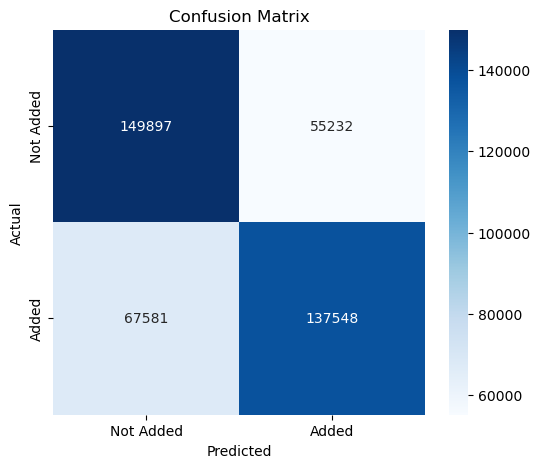

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Added','Added'],
            yticklabels=['Not Added','Added'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


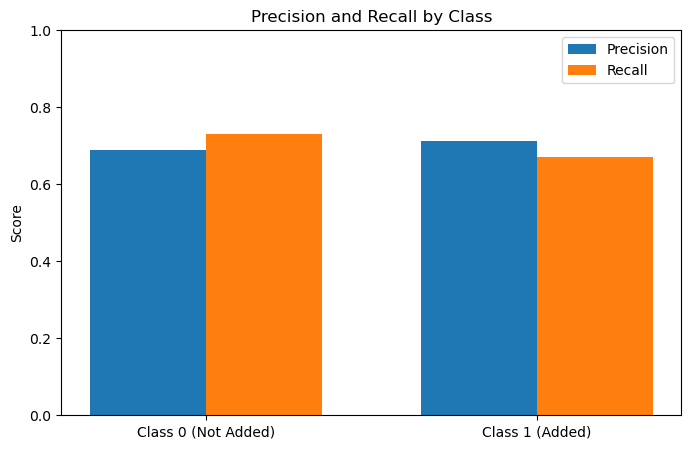

In [24]:
from sklearn.metrics import precision_score, recall_score

prec0 = precision_score(y_test, y_pred, pos_label=0)
rec0 = recall_score(y_test, y_pred, pos_label=0)
prec1 = precision_score(y_test, y_pred, pos_label=1)
rec1 = recall_score(y_test, y_pred, pos_label=1)

labels = ['Class 0 (Not Added)', 'Class 1 (Added)']
precision_vals = [prec0, prec1]
recall_vals = [rec0, rec1]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, precision_vals, width, label='Precision')
plt.bar(x + width/2, recall_vals, width, label='Recall')
plt.xticks(x, labels)
plt.ylim(0,1)
plt.ylabel('Score')
plt.title('Precision and Recall by Class')
plt.legend()
plt.show()


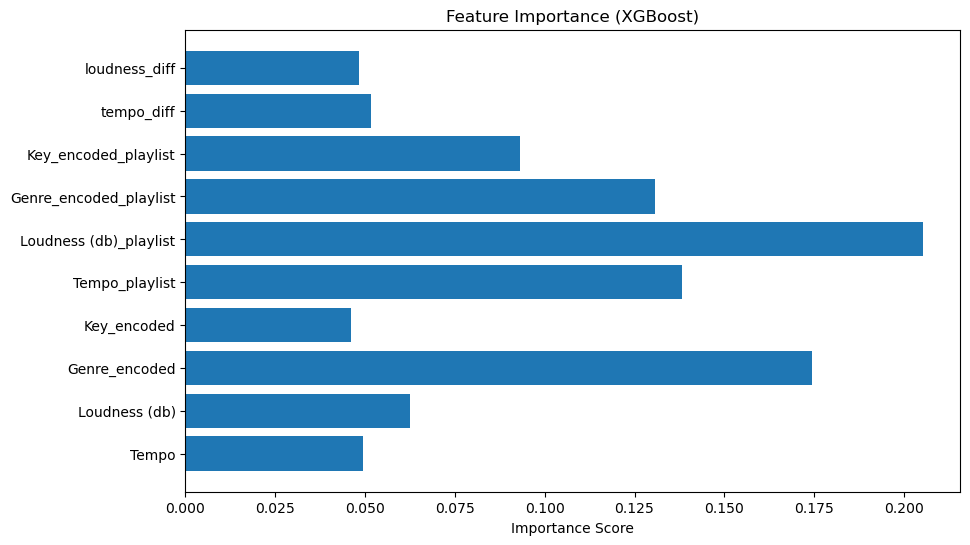

In [25]:
importances = model.feature_importances_
plt.figure(figsize=(10,6))
plt.barh(feature_cols, importances)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.show()


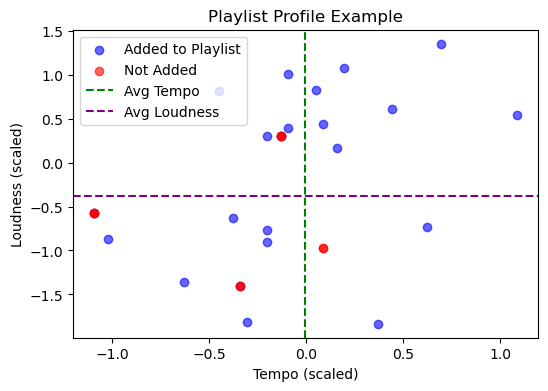

In [30]:
# Pick one playlist from train_data
playlist_example = train_data[train_data['playlistname'] == train_data['playlistname'].iloc[0]]

avg_tempo = playlist_example['Tempo_playlist'].iloc[0]
avg_loudness = playlist_example['Loudness (db)_playlist'].iloc[0]

plt.figure(figsize=(6,4))

# Plot added songs (label = 1) in blue
added = playlist_example[playlist_example['added_label'] == 1]
plt.scatter(added['Tempo'], added['Loudness (db)'], color='blue', alpha=0.6, label='Added to Playlist')

# Plot not-added songs (label = 0) in red
not_added = playlist_example[playlist_example['added_label'] == 0]
plt.scatter(not_added['Tempo'], not_added['Loudness (db)'], color='red', alpha=0.6, label='Not Added')

# Add playlist averages
plt.axvline(avg_tempo, color='green', linestyle='--', label='Avg Tempo')
plt.axhline(avg_loudness, color='purple', linestyle='--', label='Avg Loudness')

plt.xlabel('Tempo (scaled)')
plt.ylabel('Loudness (scaled)')
plt.title('Playlist Profile Example')
plt.legend()
plt.show()




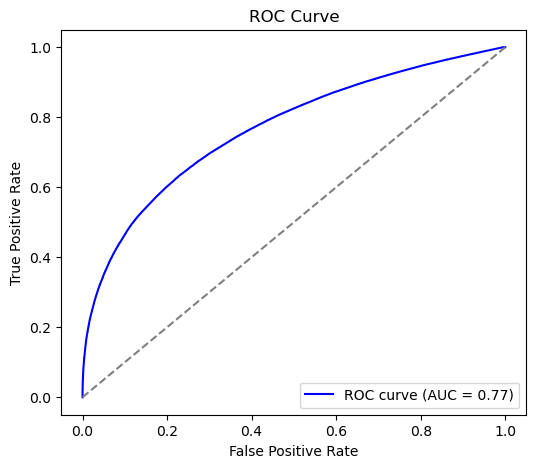

In [27]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


Heuristic Approach using Genre:

In [ ]:


print(fuzzy_merged.columns.tolist())

# Select relevant columns (make sure names match exactly)
cols_to_keep = [
    'user_id','playlistname','artistname','trackname',
    'Genre','Key','Tempo','Loudness (db)','Popularity',
    'Energy','Danceability','Positiveness','Speechiness',
    'Liveness','Acousticness','Instrumentalness'
]
data = fuzzy_merged[cols_to_keep].copy()

# Convert numeric columns explicitly
num_cols = ['Tempo','Loudness (db)','Popularity','Energy','Danceability',
            'Positiveness','Speechiness','Liveness','Acousticness','Instrumentalness']

for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop rows with missing critical values (or fill with mean if preferred)
data = data.dropna(subset=['Genre','Key'])
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

# Encode categorical features
le_genre = LabelEncoder()
data['Genre_encoded'] = le_genre.fit_transform(data['Genre'].astype(str))

le_key = LabelEncoder()
data['Key_encoded'] = le_key.fit_transform(data['Key'].astype(str))

# Scale numerical features
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

['df_index', 'df2_index', 'score', 'user_id', 'artistname', 'trackname', 'playlistname', 'artist_norm_df', 'track_norm_df', 'Artist(s)', 'song', 'text', 'Length', 'emotion', 'Genre', 'Album', 'Release Date', 'Key', 'Tempo', 'Loudness (db)', 'Time signature', 'Explicit', 'Popularity', 'Energy', 'Danceability', 'Positiveness', 'Speechiness', 'Liveness', 'Acousticness', 'Instrumentalness', 'Good for Party', 'Good for Work/Study', 'Good for Relaxation/Meditation', 'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine', 'Similar Artist 1', 'Similar Song 1', 'Similarity Score 1', 'Similar Artist 2', 'Similar Song 2', 'Similarity Score 2', 'Similar Artist 3', 'Similar Song 3', 'Similarity Score 3', 'artist_norm_df2', 'track_norm_df2']


In [12]:
# Playlist-level aggregates
playlist_features = data.groupby('playlistname').agg({
    'Tempo':'mean',
    'Loudness (db)':'mean',
    'Popularity':'mean',
    'Energy':'mean',
    'Danceability':'mean',
    'Positiveness':'mean',
    'Speechiness':'mean',
    'Liveness':'mean',
    'Acousticness':'mean',
    'Instrumentalness':'mean',
    'Genre_encoded':lambda x: x.mode()[0],
    'Key_encoded':lambda x: x.mode()[0]
}).reset_index()

# Merge back
data = data.merge(playlist_features, on='playlistname', suffixes=('','_playlist'))

# Define target: whether song matches playlist profile
# Example: label = 1 if genre matches playlist dominant genre, else 0
data['added_label'] = (data['Genre_encoded'] == data['Genre_encoded_playlist']).astype(int)

# Final feature set
X = data[['Tempo','Loudness (db)','Popularity','Energy','Danceability','Positiveness',
          'Speechiness','Liveness','Acousticness','Instrumentalness',
          'Genre_encoded','Key_encoded',
          'Tempo_playlist','Loudness (db)_playlist','Popularity_playlist','Energy_playlist',
          'Danceability_playlist','Positiveness_playlist','Speechiness_playlist',
          'Liveness_playlist','Acousticness_playlist','Instrumentalness_playlist',
          'Genre_encoded_playlist','Key_encoded_playlist']]
y = data['added_label']


In [14]:
from xgboost import XGBClassifier

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

Accuracy: 0.9851515299161957
Precision: 0.9645350770253796
Recall: 0.9901774878640777
F1: 0.9771880906488014

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     55728
           1       0.96      0.99      0.98     26368

    accuracy                           0.99     82096
   macro avg       0.98      0.99      0.98     82096
weighted avg       0.99      0.99      0.99     82096



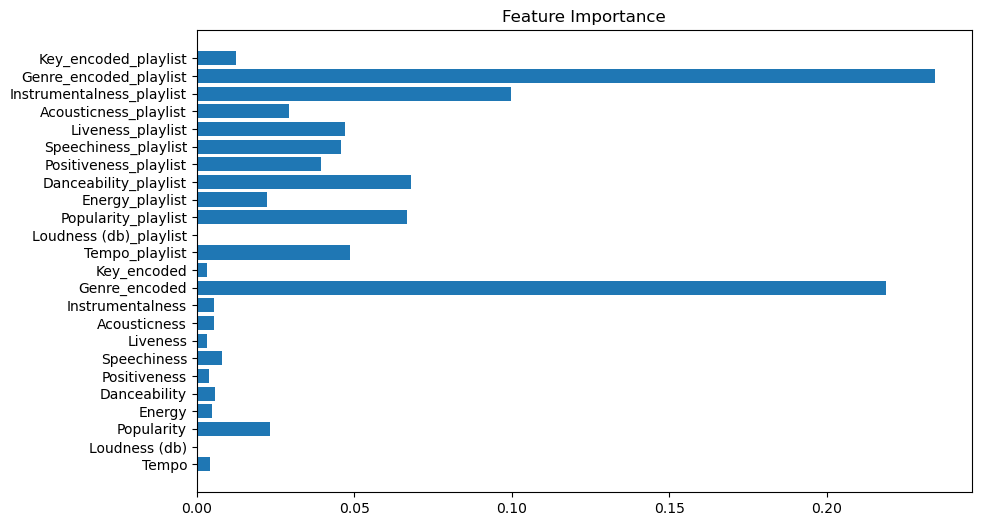

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature importance
importances = model.feature_importances_
plt.figure(figsize=(10,6))
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()